In [ ]:
import torchvision
#数字图片数据集，用于训练模型识别数字
# root告诉MNIST数据在哪里，train表明是训练集还是测试集，
# download表示是否要下载，一般设为True就行，
# 如果没下载过会自动从官网下载，
# 这个路径下下载过就不会给你下了

train_set=torchvision.datasets.MNIST(root='./dataset/mnist',train=True,download=True)
test_set=torchvision.datasets.MNIST(root='./dataset/mnist',train=False,download=True)


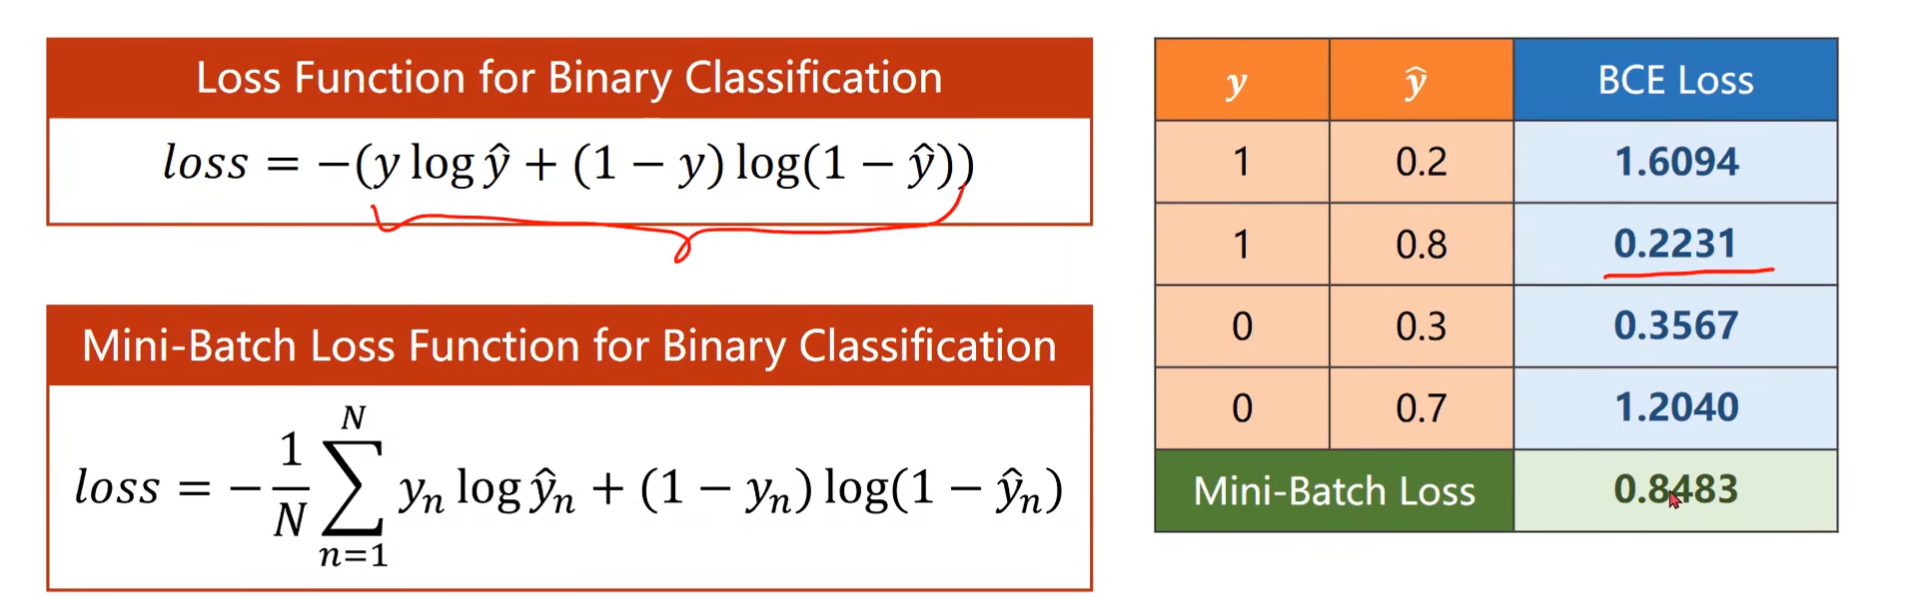
评估两分布的差异大小，所以我们训练时要使它越小越好
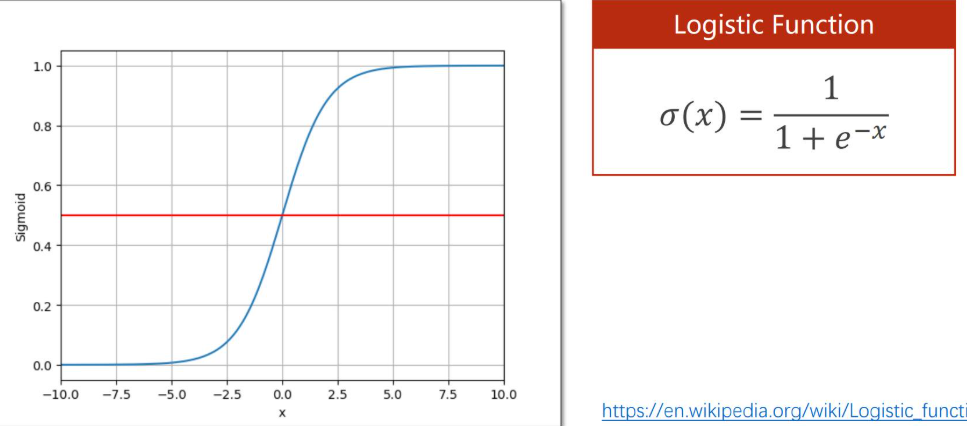
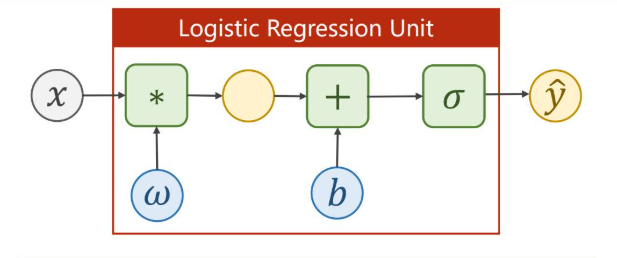

0 0.6677547097206116
1 0.6500334739685059
2 0.6358038783073425
3 0.6244084239006042
4 0.6152713298797607
5 0.607907235622406
6 0.6019188761711121
7 0.5969882607460022
8 0.5928656458854675
9 0.5893572568893433
10 0.5863143801689148
11 0.5836235880851746
12 0.5811992287635803
13 0.5789764523506165
14 0.5769067406654358
15 0.574953556060791
16 0.5730897188186646
17 0.5712947249412537
18 0.5695533752441406
19 0.5678542256355286
20 0.5661888718605042
21 0.5645509362220764
22 0.5629356503486633
23 0.5613394379615784
24 0.5597597360610962
25 0.5581944584846497
26 0.5566422343254089
27 0.5551018714904785
28 0.553572416305542
29 0.5520532727241516
30 0.550544023513794
31 0.5490441918373108
32 0.5475534796714783
33 0.5460717082023621
34 0.5445985794067383
35 0.5431340336799622
36 0.5416777729988098
37 0.5402299761772156
38 0.538790225982666
39 0.5373587012290955
40 0.5359351634979248
41 0.5345194935798645
42 0.5331117510795593
43 0.5317118763923645
44 0.5303196907043457
45 0.5289352536201477
46 

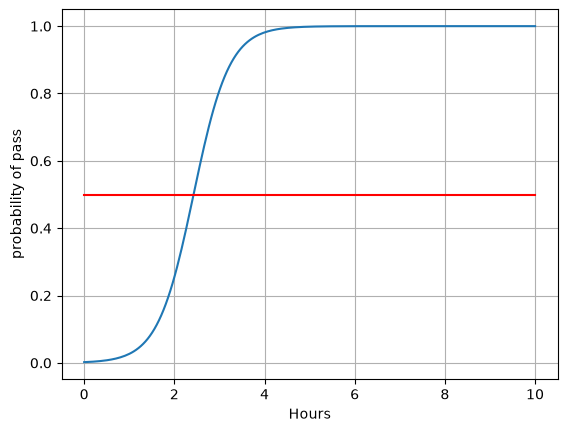

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
#x表示每周学习多长时间
#y表示是否能通过考试
x_data=torch.tensor([[1.],[2.],[3.]])
y_data=torch.tensor([[0.],[0.],[1.]])#为真的概率
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear=torch.nn.Linear(1,1)
    def forward(self,x):
        return torch.sigmoid(self.linear(x))#logistic function/sigmoid function
model=LogisticRegressionModel()
criterion=torch.nn.BCELoss()#交叉熵
optimizer=torch.optim.SGD(model.parameters(),lr=0.1)
for epoch in range(1000):
    y_pred=model(x_data)
    loss=criterion(y_pred,y_data)
    print(epoch,loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
x=np.linspace(0,10,200)
x_t=torch.tensor(x,dtype=torch.float32).view(200,1)#变成200*1的矩阵
y_t=model(x_t)
y=y_t.data.numpy()
plt.plot(x,y)
plt.plot([0,10],[0.5,0.5],c='r')
plt.xlabel('Hours')
plt.ylabel('probability of pass')
plt.grid()
plt.show()